# Import

In [1]:
import numpy as np
import pandas as pd
from math import sqrt 
import matplotlib.pyplot as plt 
from matplotlib import rcParams
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Flatten
from keras.layers import TimeDistributed
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


#%matplotlib inline
#%tensorflow_version 1.x
import tensorflow as tf
print(tf.__version__)


2.19.0


## load dataset

In [2]:
# 1) Load & merge two stations 
stations = ['Secunda', 'Ermelo']

In [3]:
# 1) Load & merge two stations 
stations = ['Secunda', 'Ermelo']
dfs = []
for st in stations:
    df = pd.read_csv(f'C:\\Users\\User\\Documents\\GitHub\\Health-impacts-of-air-pollution\\AirData\\{st}IM.csv', sep=';', header=0, index_col=0)
    # rename to keep track
    df.columns = [f'{st}_{c}' for c in df.columns]
    dfs.append(df)
data = pd.concat(dfs, axis=1).dropna()

values = data.values

## Plot pm2.5

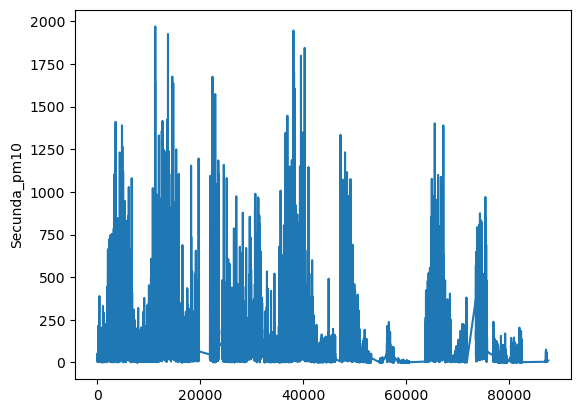

In [4]:
plt.plot(values[:,0])
plt.ylabel(data.columns[0])
plt.show()

## Data preparation

We need a way to prepare the data for whatever way we would like to formulate the problem.

In this case we are formulating it such that we take in 1 time step input (14 variables) and output 1 time step output (1 variable). In other words we are trying to solve the following question: given the pollution and weather conditions of the previous hour, can we predict the PM2.5 level for the next hour.

The single variable we are outputing is the PM2.5 level. Note we also use PM2.5 level in our input.

Credit for this code: https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/

In [5]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

## Get column names

In [6]:
data.columns

Index(['Secunda_pm10', 'Secunda_pm2.5', 'Secunda_so2', 'Secunda_no2',
       'Secunda_no', 'Secunda_nox', 'Secunda_o3', 'Secunda_co', 'Secunda_ws',
       'Secunda_wd', 'Secunda_temp', 'Secunda_relHum', 'Secunda_pressure',
       'Ermelo_pm10', 'Ermelo_pm2.5', 'Ermelo_so2', 'Ermelo_no2', 'Ermelo_no',
       'Ermelo_nox', 'Ermelo_o3', 'Ermelo_co', 'Ermelo_ws', 'Ermelo_wd',
       'Ermelo_temp', 'Ermelo_relHum', 'Ermelo_pressure'],
      dtype='object')

##Actually perform the data preparation

We scale the values between 0 and 1.

The code which converts the data into the suitable way we want, in this case, will produce 14 output variables. In our case we only want to predict PM2.5, that is why we drop the other collumns from the dataframe.

Credit for this code: https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/

In [7]:
# ensure all data is float
values = values.astype('float32')

# normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

In [8]:
# frame as supervised learning
reframed = series_to_supervised(scaled, 1, 1)

n_vars = scaled.shape[1] 

drop = list(range(n_vars+1, 2*n_vars))
reframed.drop(reframed.columns[drop], axis=1, inplace=True)
values = reframed.values

## View the data

In [9]:
reframed.head()

,var1(t-1),var2(t-1),var3(t-1),var4(t-1),var5(t-1),var6(t-1),var7(t-1),var8(t-1),var9(t-1),var10(t-1),...,var18(t-1),var19(t-1),var20(t-1),var21(t-1),var22(t-1),var23(t-1),var24(t-1),var25(t-1),var26(t-1),var1(t)
1,0.006100,0.011986,0.023296,0.092911,0.004285,0.008461,0.112376,0.002042,0.090452,0.590283,...,0.011332,0.011225,0.364375,0.0029,0.316107,0.228985,0.471635,0.858211,0.169818,0.002865
2,0.002865,0.006124,0.023639,0.092911,0.003727,0.008961,0.112376,0.001518,0.132328,0.354881,...,0.011131,0.014985,0.344774,0.0039,0.269799,0.398161,0.470346,0.854179,0.169861,0.006125
3,0.006125,0.013940,0.021446,0.092911,0.005609,0.027036,0.112376,0.002042,0.251256,0.194289,...,0.005864,0.008854,0.352574,0.0019,0.156376,0.598172,0.474214,0.847099,0.169943,0.005003
4,0.005003,0.011498,0.030219,0.092911,0.004982,0.034272,0.112376,0.001518,0.263819,0.164342,...,0.006968,0.011730,0.360074,0.0039,0.189262,0.704511,0.469572,0.881514,0.170065,0.003967
5,0.003967,0.008492,0.026175,0.092911,0.005121,0.023401,0.112376,0.000995,0.187605,0.205595,...,0.007670,0.017130,0.415077,0.0049,0.277852,0.810517,0.453584,0.865290,0.170225,0.006252


## Create X and Y variables

In [10]:
values.shape

(87646, 27)

In [11]:
X = values[:,:-1]

In [12]:
Y = values[:,-1]

## Check the shapes

In [13]:
X.shape

(87646, 26)

In [14]:
Y.shape

(87646,)

## Reshaping

reshape from [samples, timesteps] into [samples, timesteps, stations, timesteps, features] #(samples, timesteps, height, width, channels)

In [15]:
n_stations = len(stations)  
n_feats    = int(n_vars / n_stations)
n_in      = 1

In [16]:
X = X.reshape(X.shape[0],n_in,n_stations,n_feats,1)

In [17]:
X.shape

(87646, 1, 2, 13, 1)

## Training, validation and testing split

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.20, random_state=42)

## Check the shape

In [19]:
print ('X_train:',X_train.shape)
print ('Y_train:',Y_train.shape)
print ()
print ('X_val:',X_val.shape)
print ('Y_val:',Y_val.shape)
print ()
print ('X_test:',X_test.shape)
print ('Y_test:',Y_test.shape)

X_train: (56092, 1, 2, 13, 1)
Y_train: (56092,)

X_val: (14024, 1, 2, 13, 1)
Y_val: (14024,)

X_test: (17530, 1, 2, 13, 1)
Y_test: (17530,)


## Define a model
Credit for this code: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

In [20]:
model = Sequential()
# 2) apply a small 2D conv over the station×feature “grid” at each time step
model.add(TimeDistributed(Conv2D(filters=64,kernel_size=(2,2),      # your choice; must be <= (n_stations, n_feats)
      activation='relu', padding='same'),input_shape=(None, n_stations, n_feats, 1)))
model.add(TimeDistributed(MaxPooling2D(pool_size=(2,2))))
model.add(TimeDistributed(Conv2D(filters=64,kernel_size=(2,2), activation='relu', padding='same')))
model.add(TimeDistributed(MaxPooling2D(pool_size=(1,2))))
model.add(TimeDistributed(Conv2D(filters=64,kernel_size=(2,2), activation='relu', padding='same')))
model.add(TimeDistributed(MaxPooling2D(pool_size=(1,2))))
model.add(TimeDistributed(Flatten()))
model.add(LSTM(56))
model.add(Dense(56, activation="relu"))
model.add(Dense(56, activation="relu"))
model.add(Dense(1, activation='linear'))   # use 'linear' for regression
model.compile(loss='mse', optimizer='adam')

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Print summary

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 2, 13,    │           320 │
│ (TimeDistributed)               │ 64)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, None, 1, 6, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 1, 6, 64) │        16,448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 1, 3, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, None, 1, 3, 64) │        16,448 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, None, 1, 1, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, None, 64)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 56)             │        27,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 56)             │         3,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 56)             │         3,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,761 (260.79 KB)

 Trainable params: 66,761 (260.79 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [22]:
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=40, batch_size=32, verbose=1)

Epoch 1/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 2/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.0011 - val_loss: 9.0298e-04
Epoch 3/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 4/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 9.7517e-04 - val_loss: 9.5131e-04
Epoch 5/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0010 - val_loss: 8.6465e-04
Epoch 6/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 9.2961e-04 - val_loss: 9.1186e-04
Epoch 7/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 8.9861e-04 - val_loss: 9.0278e-04
Epoch 8/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 9.5723e-04 - val_loss: 9.2145e-04
Epoch 9/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 9.6925e-04 - val_loss: 8.6874e-04
Epoch 10/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 9.1521e-04 - val_loss: 9.6511e-04
Epoch 11/40
1753/1753 ━━━━━━━━━━━━━━━━━━━━ 

# Plot the performance

## Predict

In [23]:
prediction = model.predict(X_test)

548/548 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [24]:
def unscale(scaled_value):
    # if target variable is the first column, then, data_max_[0]
    unscaled_value = scaled_value * (scaler.data_max_[0] - scaler.data_min_[0]) + (scaler.data_min_[0])
    return unscaled_value

In [25]:
predictions = unscale(prediction)

In [26]:
Y_tests = unscale(Y_test)

In [27]:
mae = mean_absolute_error(Y_tests, predictions)

In [28]:
rmse = sqrt(mean_squared_error(Y_tests, predictions))

In [29]:
r2 = r2_score(Y_tests, predictions)

In [30]:
print(f"MAE:  {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²:   {r2:.6f}")

MAE:  24.805809
RMSE: 62.534289
R²:   0.631393


# Plot the performance

## Compare prediction and testing data

In [ ]:
rcParams['font.weight'] = 'bold'
plt.plot(Y_tests[0:240], color='blue', label = 'Observed')
plt.plot(predictions[0:240], color='red', label = 'Predicted')
plt.ylabel('PM2.5', fontname="Times New Roman", size=20,fontweight="bold")
plt.xlabel('Time(Hrs)', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('Secunda CNNLSTM Model', fontname="Times New Roman", size=28,fontweight="bold")
legend_properties = {'weight':'bold'}
plt.legend(prop=legend_properties)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/2DCNNLSTM/Sec2DCNNLSTMPred_PM2.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
## Calculate errors
errors = predictions.flatten() - Y_tests

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(Y_tests, q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((Y_tests >= bins[i]) & (Y_tests < bins[i+1]))[0]
    quantile_errors.append(errors[group_indices].mean())

# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20,fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20,fontweight="bold")
plt.title('Secunda CNNLSTM Model', fontname="Times New Roman", size=28,fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [str(q) for q in quantiles.categories], rotation=45)
plt.grid(True)
plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/2DCNNLSTM/Sec2DCNNLSTMQuan_PM2.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
errors = predictions.flatten() - Y_tests

# Calculate quantiles based on actual values
quantiles, bins = pd.qcut(Y_tests, q=10, duplicates='drop', retbins=True)

# Calculate average error for each quantile
quantile_errors = []
for i in range(len(bins) - 1):
    group_indices = np.where((Y_tests >= bins[i]) & (Y_tests < bins[i+1]))[0]
    quantile_errors.append(errors[group_indices].mean())

# Round the bin edges for better readability
rounded_bins = np.round(bins, decimals=3)

# Plot quantiles vs. average errors
rcParams['font.weight'] = 'bold'
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(quantiles.categories) + 1), quantile_errors, marker='o')
plt.xlabel('Quantile', fontname="Times New Roman", size=20, fontweight="bold")
plt.ylabel('Average Error', fontname="Times New Roman", size=20, fontweight="bold")
plt.title('Secunda CNNLSTM Model', fontname="Times New Roman", size=28, fontweight="bold")
plt.xticks(range(1, len(quantiles.categories) + 1), [f'{rounded_bins[i]:.3f} - {rounded_bins[i+1]:.3f}' for i in range(len(rounded_bins) - 1)], rotation=45)
plt.grid(True)
plt.show()

# SHAP

In [ ]:
# ─── PART 3: SHAP EXPLAINER ───
# Run this only after you’ve trained your 2D CNN–LSTM model above,
# and in a fresh kernel (so that shap isn’t already imported).

import shap
import numpy as np

# 1) Flatten your inputs:
#    X_train.shape == (N, 1, n_stations, n_feats, 1)
#    -> bg_flat.shape == (N, n_stations*n_feats)
bg_flat  = X_train.reshape(X_train.shape[0], -1)
test_flat = X_test.reshape(X_test.shape[0], -1)

# 2) Subsample for speed
B = min(300, bg_flat.shape[0])
T = min(60, test_flat.shape[0])
bg_idx   = np.random.choice(bg_flat.shape[0], B, replace=False)
test_idx = np.random.choice(test_flat.shape[0], T, replace=False)
bg_sample   = bg_flat[bg_idx]
test_sample = test_flat[test_idx]

# 3) Wrap your model’s predict to accept 2D arrays
f = lambda x: model.predict(
    x.reshape(-1, 1, n_stations, n_feats, 1)
).flatten()

# 4) Build the explainer & compute SHAP values
explainer   = shap.KernelExplainer(f, bg_sample)
shap_values = explainer.shap_values(test_sample)

# 5) Plot summary
feat_names = data.columns.tolist()  # length == n_stations * n_feats
shap.summary_plot(
    shap_values,
    test_sample,
    feature_names=feat_names,
    show=False
)
plt.title('Secunda CNNLSTM Model', fontweight='bold', size=14)

plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/2DCNNLSTM/Sec2DCNNLSTMshap_PM2.png", dpi=300, bbox_inches='tight')

In [ ]:
# 5) Plot summary
feat_names = data.columns.tolist()  # length == n_stations * n_feats
shap.summary_plot(
    shap_values,
    test_sample,
    feature_names=feat_names,
    show=False
)
plt.title('eMalahleni CNNLSTM Model', fontweight='bold', size=14)

plt.savefig("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/2DCNNLSTM/eMa2DCNNLSTMshap_PM2.png", dpi=300, bbox_inches='tight')

# SAVE THE MODEL

In [ ]:
# eMalahleni PM2.5
model.save('2Dlstmcnn_model.h5')
#model.save('2Dlstmcnn_modelPM1.h5')
#model.save('2Dlstmcnn_modelSO2.h5')
#model.save('2Dlstmcnn_modelNO2.h5')

In [ ]:
# Ermelo PM2.5
model.save('2Dlstmcnn_modelEPM2.h5')
#model.save('2Dlstmcnn_modelEPM1.h5')
#model.save('2Dlstmcnn_modelESO2.h5')
#model.save('2Dlstmcnn_modelENO2.h5')

In [ ]:
# Hendrina PM2.5
#model.save('2Dlstmcnn_modelHPM2.h5')
#model.save('2Dlstmcnn_modelHPM1.h5')
#model.save('2Dlstmcnn_modelHSO2.h5')
#model.save('2Dlstmcnn_modelHNO2.h5')

In [ ]:
# Middelburg PM2.5
model.save('2Dlstmcnn_modelMPM2.h5')
#model.save('2Dlstmcnn_modelMPM1.h5')
#model.save('2Dlstmcnn_modelMSO2.h5')
#model.save('2Dlstmcnn_modelMNO2.h5')

In [ ]:
# Secunda PM2.5
model.save('2Dlstmcnn_modelSPM2.h5')
#model.save('2Dlstmcnn_modelSPM1.h5')
#model.save('2Dlstmcnn_modelSSO2.h5')
#model.save('2Dlstmcnn_modelSNO2.h5')

# SAVE THE RESULTS

In [ ]:
results_df = pd.DataFrame({
    'actual': Y_tests.ravel(),
    'predicted': predictions.ravel(),
    'error': errors.ravel()
})

results_df.to_csv("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/2DCNNLSTM/Sec2DCNNLSTM_predictions_PM2.csv", index=False)

In [ ]:
# Save metrics
metrics_dict = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_df.to_csv("C:/Users/User/Documents/GitHub/Health-impacts-of-air-pollution/PLOTS/2DCNNLSTM/Sec2DCNNLSTM_metrics_PM2.csv", index=False)